This notebook contains code to generate and save plots comparing quantities predicted by the RISS19 model to quantities determined by our analysis using observations from VAST. It will save these plots to a folder named 'comparison_plots', which must exist prior to running this notebook. It additionally contains functions for creating generic linear- and log-axis scatter plots with on-axis histograms. It should be run after all other notebooks in this set, as it requires data from both 'make_acf' notebooks and the RISS19 model.

PRECONDITION: a folder named 'comparison_plots' must exist in this directory.

IN: 'paper_dfv5.csv'

OUT: eight plots comparing RISS19 predictions to our computed quantities, which will be found in the aforementioned 'comparison_plots' folder

In [1]:
# importing required modules
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# setting plot preferences
%matplotlib inline
plt.rcParams['text.usetex'] = True

In [3]:
data = pd.read_csv('paper_dfv5.csv')

In [12]:
#computing percent differences compared to model
mod_dif_raw = ((data['modulation']) - data['m'])/ data['m']
mod_dif_raw_err = ((data['modulation_err'].pow(2) + data['err_m'].pow(2)).div(((data['modulation']) - data['m']).pow(2)) + data['err_m'].div(data['m']).pow(2)).pow(0.5).mul(mod_dif_raw)

t_dif_raw = (data['t_decorrelation'] - (data['t0']))/ (data['t0'])
t_dif_raw_err = ((data['t_decorrelation_err'].pow(2) + data['err_t0'].pow(2)).div((data['t_decorrelation'] - data['t0']).pow(2)) + data['err_t0'].div(data['t0']).pow(2)).pow(0.5).mul(t_dif_raw)

mod_dif_corrected = ((data['corrected_modulation']) - data['m'])/ data['m']
mod_dif_corrected_err = ((data['corrected_modulation_err'].pow(2) + data['err_m'].pow(2)).div(((data['corrected_modulation']) - data['m']).pow(2)) + data['err_m'].div(data['m']).pow(2)).pow(0.5).mul(mod_dif_corrected)

t_dif_corrected = (data['t_decorrelation_corrected'] - (data['t0']))/ (data['t0'])
t_dif_corrected_err = ((data['t_decorrelation_corrected_err'].pow(2) + data['err_t0'].pow(2)).div((data['t_decorrelation_corrected'] - data['t0']).pow(2)) + data['err_t0'].div(data['t0']).pow(2)).pow(0.5).mul(t_dif_corrected)

In [43]:
#computing ratioes compared to models
mod_ratio_raw = data['modulation'] / data['m']
mod_ratio_raw_err = ((data['modulation_err'].div(data['modulation']).pow(2)) + (data['err_m'].div(data['m']).pow(2))).pow(0.5).mul(mod_ratio_raw)

t_ratio_raw = data['t_decorrelation'] / data['t0']
t_ratio_raw_err = ((data['t_decorrelation_err'].div(data['t_decorrelation']).pow(2)) + (data['err_t0'].div(data['t0']).pow(2))).pow(0.5).mul(t_ratio_raw)

mod_ratio_corrected = data['corrected_modulation'] / data['m']
mod_ratio_corrected_err = ((data['corrected_modulation_err'].div(data['corrected_modulation']).pow(2)) + (data['err_m'].div(data['m']).pow(2))).pow(0.5).mul(mod_ratio_corrected)

t_ratio_corrected = data['t_decorrelation'] / data['t0']
t_ratio_corrected_err = ((data['t_decorrelation_err'].div(data['t_decorrelation']).pow(2)) + (data['err_t0'].div(data['t0']).pow(2))).pow(0.5).mul(t_ratio_corrected)

In [9]:
def scatter_hist(x, y, ax, ax_histx, ax_histy):
    # no labels
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)

    # the scatter plot:
    ax.scatter(x, y, marker='.')

    # now determine nice limits by hand:
    binwidth = 0.25
    xymax = max(np.max(np.abs(x)), np.max(np.abs(y)))
    #lim = (int(xymax/binwidth) + 1) * binwidth

    #bins = np.arange(-lim, lim + binwidth, binwidth)
    ax_histx.hist(x, color='k')
    ax_histy.hist(y, orientation='horizontal', color='k')

c:\users\benlo\appdata\local\programs\python\python39\lib\site-packages\numpy\core\_methods.py:44: RuntimeWarning: invalid value encountered in reduce
  return umr_minimum(a, axis, None, out, keepdims, initial, where)
c:\users\benlo\appdata\local\programs\python\python39\lib\site-packages\numpy\core\_methods.py:40: RuntimeWarning: invalid value encountered in reduce
  return umr_maximum(a, axis, None, out, keepdims, initial, where)


Text(0, 0.5, '$\\displaystyle\\frac{\\tau_{observed} - \\tau_{model}}{\\tau_{model}}$')

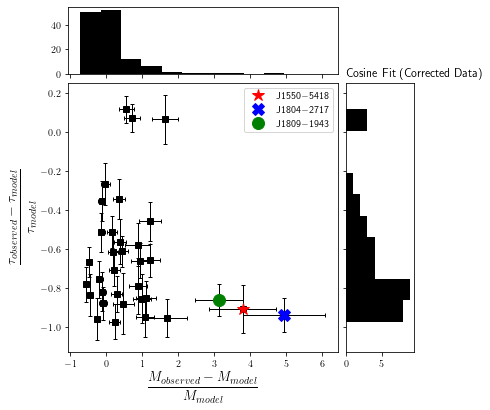

In [14]:
#plotting percent difference with raw fluxes and errors.
#NB: in this cell the data is not limited to pulsars with a certain amount of variability. Adding a floor for variability may be a good idea.
x = mod_dif_raw
x_err = np.abs(mod_dif_raw_err)
y = t_dif_raw
y_err = np.abs(t_dif_raw_err)
# Start with a square Figure.
fig = plt.figure(figsize=(6, 6))
# Add a gridspec with two rows and two columns and a ratio of 1 to 4 between
# the size of the marginal Axes and the main Axes in both directions.
# Also adjust the subplot parameters for a square plot.
gs = fig.add_gridspec(2, 2,  width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)
# Create the Axes.
ax = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
# Draw the scatter plot and marginals.
scatter_hist(x, y, ax, ax_histx, ax_histy)
ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='sk', elinewidth=1, capsize=2)

#labeling outliers. the 'label' kwarg must be manually input to make sure that a minus sign is used instead of a dash.
ax.plot(x[17], y[17], 'r*', ms=12, zorder=3, label=r'J1550$-$5418')
ax.plot(x[6], y[6], 'bX', ms=12, zorder=3, label=r'J1804$-$2717')
ax.plot(x[16], y[16], 'go', ms=12, zorder=3, label=r'J1809$-$1943')
#end labeling

ax.legend()
plt.title("Raw Data (% Difference)", loc='left')
ax.set_xlabel(r'$\displaystyle\frac{M_{observed} - M _{model}}{M_{model}}$', fontsize=14)
ax.set_ylabel(r'$\displaystyle\frac{\tau_{observed} - \tau_{model}}{\tau_{model}}$', fontsize=14)
plt.savefig('comparison_plots/raw_diff_scatter.png', bbox_inches='tight', pad_inches=0.2)

c:\users\benlo\appdata\local\programs\python\python39\lib\site-packages\numpy\core\_methods.py:44: RuntimeWarning: invalid value encountered in reduce
  return umr_minimum(a, axis, None, out, keepdims, initial, where)
c:\users\benlo\appdata\local\programs\python\python39\lib\site-packages\numpy\core\_methods.py:40: RuntimeWarning: invalid value encountered in reduce
  return umr_maximum(a, axis, None, out, keepdims, initial, where)


Text(0, 0.5, '$\\displaystyle\\frac{\\tau_{observed} - \\tau_{model}}{\\tau_{model}}$')

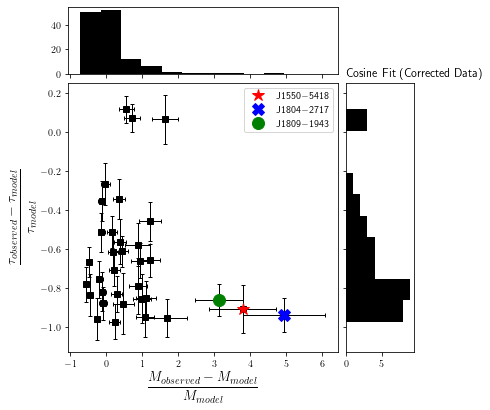

In [14]:
#creating the same plot as above, this time with the corrected fluxes
#NB: in this cell the data is not limited to pulsars with a certain amount of variability. Adding a floor for variability may be a good idea.
x = mod_dif_corrected
x_err = np.abs(mod_dif_corrected_err)
y = t_dif_corrected
y_err = np.abs(t_dif_corrected_err)
# Start with a square Figure.
fig = plt.figure(figsize=(6, 6))
# Add a gridspec with two rows and two columns and a ratio of 1 to 4 between
# the size of the marginal Axes and the main Axes in both directions.
# Also adjust the subplot parameters for a square plot.
gs = fig.add_gridspec(2, 2,  width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)
# Create the Axes.
ax = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
# Draw the scatter plot and marginals.
scatter_hist(x, y, ax, ax_histx, ax_histy)
ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='sk', elinewidth=1, capsize=2)

#labeling outliers. the 'label' kwarg must be manually input to make sure that a minus sign is used instead of a dash.
ax.plot(x[17], y[17], 'r*', ms=12, zorder=3, label=r'J1550$-$5418')
ax.plot(x[6], y[6], 'bX', ms=12, zorder=3, label=r'J1804$-$2717')
ax.plot(x[16], y[16], 'go', ms=12, zorder=3, label=r'J1809$-$1943')
#end labeling

ax.legend()
plt.title("Corrected Data (% Difference)", loc='left')
ax.set_xlabel(r'$\displaystyle\frac{\hat{M_{observed}} - M _{model}}{M_{model}}$', fontsize=14)
ax.set_ylabel(r'$\displaystyle\frac{\hat{\tau_{observed}} - \tau_{model}}{\tau_{model}}$', fontsize=14)
plt.savefig('comparison_plots/corrected_diff_scatter.png', bbox_inches='tight', pad_inches=0.2)

c:\users\benlo\appdata\local\programs\python\python39\lib\site-packages\numpy\core\_methods.py:44: RuntimeWarning: invalid value encountered in reduce
  return umr_minimum(a, axis, None, out, keepdims, initial, where)
c:\users\benlo\appdata\local\programs\python\python39\lib\site-packages\numpy\core\_methods.py:40: RuntimeWarning: invalid value encountered in reduce
  return umr_maximum(a, axis, None, out, keepdims, initial, where)


Text(0, 0.5, '$\\displaystyle\\frac{\\tau_{observed} - \\tau_{model}}{\\tau_{model}}$')

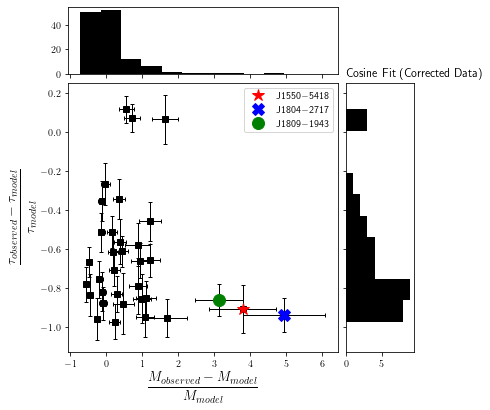

In [14]:
#plotting ratios with raw fluxes
#NB: in this cell the data is not limited to pulsars with a certain amount of variability. Adding a floor for variability may be a good idea.
x = mod_ratio_raw
x_err = np.abs(mod_ratio_raw_err)
y = t_ratio_raw
y_err = np.abs(t_ratio_raw_err)
# Start with a square Figure.
fig = plt.figure(figsize=(6, 6))
# Add a gridspec with two rows and two columns and a ratio of 1 to 4 between
# the size of the marginal Axes and the main Axes in both directions.
# Also adjust the subplot parameters for a square plot.
gs = fig.add_gridspec(2, 2,  width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)
# Create the Axes.
ax = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
# Draw the scatter plot and marginals.
scatter_hist(x, y, ax, ax_histx, ax_histy)
ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='sk', elinewidth=1, capsize=2)

#labeling outliers. the 'label' kwarg must be manually input to make sure that a minus sign is used instead of a dash.
ax.plot(x[17], y[17], 'r*', ms=12, zorder=3, label=r'J1550$-$5418')
ax.plot(x[6], y[6], 'bX', ms=12, zorder=3, label=r'J1804$-$2717')
ax.plot(x[16], y[16], 'go', ms=12, zorder=3, label=r'J1809$-$1943')
#end labeling

ax.legend()
plt.title("Raw Data (Ratios)", loc='left')
ax.set_xlabel(r'$\displaystyle\frac{M_{observed}}{M_{model}}$', fontsize=14)
ax.set_ylabel(r'$\displaystyle\frac{\tau_{observed}}{\tau_{model}}$', fontsize=14)
plt.savefig('comparison_plots/raw_ratio_scatter.png', bbox_inches='tight', pad_inches=0.2)

c:\users\benlo\appdata\local\programs\python\python39\lib\site-packages\numpy\core\_methods.py:44: RuntimeWarning: invalid value encountered in reduce
  return umr_minimum(a, axis, None, out, keepdims, initial, where)
c:\users\benlo\appdata\local\programs\python\python39\lib\site-packages\numpy\core\_methods.py:40: RuntimeWarning: invalid value encountered in reduce
  return umr_maximum(a, axis, None, out, keepdims, initial, where)


Text(0, 0.5, '$\\displaystyle\\frac{\\tau_{observed} - \\tau_{model}}{\\tau_{model}}$')

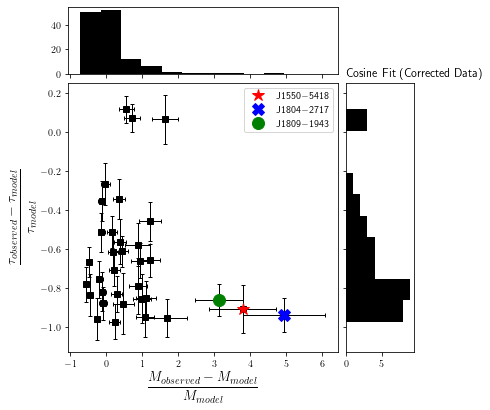

In [14]:
#plotting ratios with corrected fluxes
#NB: in this cell the data is not limited to pulsars with a certain amount of variability. Adding a floor for variability may be a good idea.
x = mod_ratio_corrected
x_err = np.abs(mod_ratio_corrected_err)
y = t_ratio_corrected
y_err = np.abs(t_ratio_corrected_err)
# Start with a square Figure.
fig = plt.figure(figsize=(6, 6))
# Add a gridspec with two rows and two columns and a ratio of 1 to 4 between
# the size of the marginal Axes and the main Axes in both directions.
# Also adjust the subplot parameters for a square plot.
gs = fig.add_gridspec(2, 2,  width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)
# Create the Axes.
ax = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
# Draw the scatter plot and marginals.
scatter_hist(x, y, ax, ax_histx, ax_histy)
ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='sk', elinewidth=1, capsize=2)

#labeling outliers. the 'label' kwarg must be manually input to make sure that a minus sign is used instead of a dash.
ax.plot(x[17], y[17], 'r*', ms=12, zorder=3, label=r'J1550$-$5418')
ax.plot(x[6], y[6], 'bX', ms=12, zorder=3, label=r'J1804$-$2717')
ax.plot(x[16], y[16], 'go', ms=12, zorder=3, label=r'J1809$-$1943')
#end labeling

ax.legend()
plt.title("Corrected Data (Ratios)", loc='left')
ax.set_xlabel(r'$\displaystyle\frac{\hat{M_{observed}}}{M_{model}}$', fontsize=14)
ax.set_ylabel(r'$\displaystyle\frac{\hat{\tau_{observed}}}{\tau_{model}}$', fontsize=14)
plt.savefig('comparison_plots/corrected_ratio_scatter.png', bbox_inches='tight', pad_inches=0.2)

In [9]:
def log_scatter_hist(x, y, ax, ax_histx, ax_histy):
    # no labels
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)

    # the scatter plot:
    ax.scatter(x, y, marker='.')

    # now determine nice limits by hand:
    binwidth = 0.25
    xymax = max(np.max(np.abs(x)), np.max(np.abs(y)))
    #lim = (int(xymax/binwidth) + 1) * binwidth

    xbins = np.logspace(-3, 1, 10)
    ybins = np.logspace(-22, -11, 10)
    ax_histx.hist(x, bins=xbins, color='k')
    ax_histy.hist(y, bins=ybins, orientation='horizontal', color='k')

Text(0, 0.5, 'Period derivative')

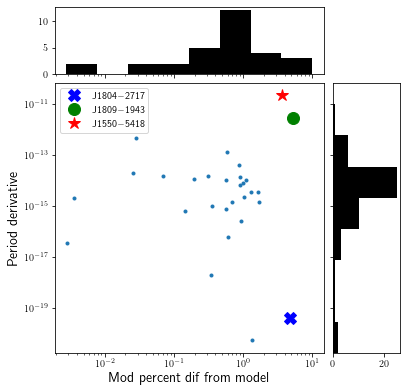

In [16]:
#plotting percent difference from model, this time with a log scatter plot and raw fluxes, and saving the plot
#the same note as above applies: there is no cutoff for variability here
x = mod_dif_raw
x_err = np.abs(mod_dif_raw_err)
y = t_dif_raw
y_err = np.abs(t_dif_raw_err)
# Start with a square Figure.
fig = plt.figure(figsize=(6, 6))
# Add a gridspec with two rows and two columns and a ratio of 1 to 4 between
# the size of the marginal Axes and the main Axes in both directions.
# Also adjust the subplot parameters for a square plot.
gs = fig.add_gridspec(2, 2,  width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)
# Create the Axes.
ax = fig.add_subplot(gs[1, 0])
ax.set_xscale('log')
ax.set_yscale('log')
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
# Draw the scatter plot and marginals.
log_scatter_hist(x, y, ax, ax_histx, ax_histy)
ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='sk', elinewidth=1, capsize=2)

#labeling outliers here. The 'label' kwarg is agin input manually to ensure a minus sign is used
ax.plot(x[6], y[6], 'bX', ms=12, zorder=3, label=r'J1804$-$2717')
ax.plot(x[16], y[16], 'go', ms=12, zorder=3, label=r'J1809$-$1943')
ax.plot(x[17], y[17], 'r*', ms=12, zorder=3, label=r'J1550$-$5418')
#end labeling

ax.legend()
plt.title("Raw Data (% Difference)", loc='left')
ax.set_xlabel(r'$\displaystyle\frac{M_{observed} - M _{model}}{M_{model}}$', fontsize=14)
ax.set_ylabel(r'$\displaystyle\frac{\tau_{observed} - \tau_{model}}{\tau_{model}}$', fontsize=14)
plt.savefig('comparison_plots/raw_dif_logscatter.png', bbox_inches='tight', pad_inches=0.2)

Text(0, 0.5, 'Period derivative')

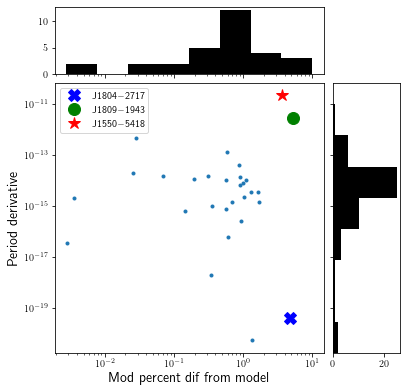

In [16]:
#plotting percent difference from model, this time with a log scatter plot and corrected fluxes, and saving the plot
#the same note as above applies: there is no cutoff for variability here
x = mod_dif_corrected
x_err = np.abs(mod_dif_corrected_err)
y = t_dif_corrected
y_err = np.abs(t_dif_corrected_err)
# Start with a square Figure.
fig = plt.figure(figsize=(6, 6))
# Add a gridspec with two rows and two columns and a ratio of 1 to 4 between
# the size of the marginal Axes and the main Axes in both directions.
# Also adjust the subplot parameters for a square plot.
gs = fig.add_gridspec(2, 2,  width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)
# Create the Axes.
ax = fig.add_subplot(gs[1, 0])
ax.set_xscale('log')
ax.set_yscale('log')
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
# Draw the scatter plot and marginals.
log_scatter_hist(x, y, ax, ax_histx, ax_histy)
ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='sk', elinewidth=1, capsize=2)

#labeling outliers here. The 'label' kwarg is agin input manually to ensure a minus sign is used
ax.plot(x[6], y[6], 'bX', ms=12, zorder=3, label=r'J1804$-$2717')
ax.plot(x[16], y[16], 'go', ms=12, zorder=3, label=r'J1809$-$1943')
ax.plot(x[17], y[17], 'r*', ms=12, zorder=3, label=r'J1550$-$5418')
#end labeling

ax.legend()
plt.title("Corrected Data (% Difference)", loc='left')
ax.set_xlabel(r'$\displaystyle\frac{\hat{M_{observed}} - M _{model}}{M_{model}}$', fontsize=14)
ax.set_ylabel(r'$\displaystyle\frac{\hat{\tau_{observed}} - \tau_{model}}{\tau_{model}}$', fontsize=14)
plt.savefig('comparison_plots/corrected_dif_logscatter.png', bbox_inches='tight', pad_inches=0.2)

Text(0, 0.5, 'Period derivative')

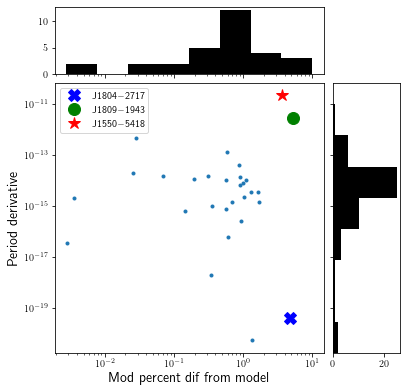

In [16]:
#plotting ratio from model, this time with a log scatter plot and raw data, and saving the plot
#the same note as above applies: there is no cutoff for variability here
x = mod_ratio_raw
x_err = np.abs(mod_ratio_raw_err)
y = t_ratio_raw
y_err = np.abs(t_ratio_raw_err)
# Start with a square Figure.
fig = plt.figure(figsize=(6, 6))
# Add a gridspec with two rows and two columns and a ratio of 1 to 4 between
# the size of the marginal Axes and the main Axes in both directions.
# Also adjust the subplot parameters for a square plot.
gs = fig.add_gridspec(2, 2,  width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)
# Create the Axes.
ax = fig.add_subplot(gs[1, 0])
ax.set_xscale('log')
ax.set_yscale('log')
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
# Draw the scatter plot and marginals.
log_scatter_hist(x, y, ax, ax_histx, ax_histy)
ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='sk', elinewidth=1, capsize=2)

#labeling outliers here. The 'label' kwarg is agin input manually to ensure a minus sign is used
ax.plot(x[6], y[6], 'bX', ms=12, zorder=3, label=r'J1804$-$2717')
ax.plot(x[16], y[16], 'go', ms=12, zorder=3, label=r'J1809$-$1943')
ax.plot(x[17], y[17], 'r*', ms=12, zorder=3, label=r'J1550$-$5418')
#end labeling

ax.legend()
plt.title("Raw Data (Ratios)", loc='left')
ax.set_xlabel(r'$\displaystyle\frac{M_{observed}}{M_{model}}$', fontsize=14)
ax.set_ylabel(r'$\displaystyle\frac{\tau_{observed}}{\tau_{model}}$', fontsize=14)
plt.savefig('comparison_plots/raw_ratio_logscatter.png', bbox_inches='tight', pad_inches=0.2)

Text(0, 0.5, 'Period derivative')

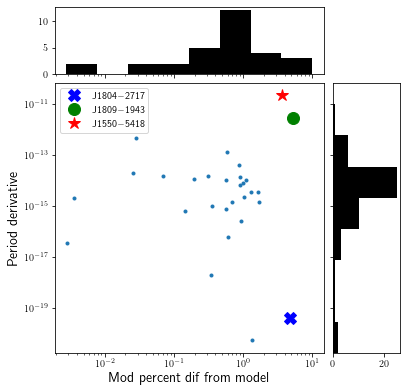

In [16]:
#plotting ratio from model, this time with a log scatter plot and corrected data, and saving the plot
#the same note as above applies: there is no cutoff for variability here
x = mod_ratio_corrected
x_err = np.abs(mod_ratio_corrected_err)
y = t_ratio_corrected
y_err = np.abs(t_ratio_corrected_err)
# Start with a square Figure.
fig = plt.figure(figsize=(6, 6))
# Add a gridspec with two rows and two columns and a ratio of 1 to 4 between
# the size of the marginal Axes and the main Axes in both directions.
# Also adjust the subplot parameters for a square plot.
gs = fig.add_gridspec(2, 2,  width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)
# Create the Axes.
ax = fig.add_subplot(gs[1, 0])
ax.set_xscale('log')
ax.set_yscale('log')
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
# Draw the scatter plot and marginals.
log_scatter_hist(x, y, ax, ax_histx, ax_histy)
ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='sk', elinewidth=1, capsize=2)

#labeling outliers here. The 'label' kwarg is agin input manually to ensure a minus sign is used
ax.plot(x[6], y[6], 'bX', ms=12, zorder=3, label=r'J1804$-$2717')
ax.plot(x[16], y[16], 'go', ms=12, zorder=3, label=r'J1809$-$1943')
ax.plot(x[17], y[17], 'r*', ms=12, zorder=3, label=r'J1550$-$5418')
#end labeling

ax.legend()
plt.title("Corrected Data (Ratios)", loc='left')
ax.set_xlabel(r'$\displaystyle\frac{\hat{M_{observed}}}{M_{model}}$', fontsize=14)
ax.set_ylabel(r'$\displaystyle\frac{\hat{\tau_{observed}}}{\tau_{model}}$', fontsize=14)
plt.savefig('comparison_plots/corrected_ratio_logscatter.png', bbox_inches='tight', pad_inches=0.2)